## JR Analyst Python Home Exam - Saar Pardo
### 26/07/2025

You’re a Junior Data Analyst given New York City crime data. You’re asked to explore patterns, find trends, and predict the next crimes in town.

You'll use the python libraries `pandas` and `matplotlib` for data manipulation and visualizations.

Please complete this exercise and document your process using a Jupyter Notebook, with clearly separated code and markdown sections.

When you finish the task, send the .ipynb file as your answer, along with your dataset if you madechanges to it.

### Section 1:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
crime_df = pd.read_csv('nyc_crime_large.csv')
# crime_df.info()

- `CMPLNT_FR_DT` : Date the crime occurred

- `OFNS_DESC` : Offense description

- `BORO_NM` : Borough

- `LAW_CAT_CD` : Crime severity

In [3]:
crime_df.head(2)

,CMPLNT_FR_DT,OFNS_DESC,BORO_NM,LAW_CAT_CD,Latitude,Longitude
0,03/24/2025,ASSAULT,BRONX,MISDEMEANOR,40.591219,-73.875608
1,02/13/2024,ASSAULT,BRONX,MISDEMEANOR,40.838128,-73.979811


a. Create two new columns: `year` and `month` from the `CMPLNT_FR_DT` column.

In [4]:
crime_df['CMPLNT_FR_DT'] = pd.to_datetime(crime_df['CMPLNT_FR_DT'], errors='coerce')

# crime_df['CMPLNT_FR_DT'].describe()

# count                          2000
# mean     2024-01-10 12:28:04.800000
# min             2022-07-16 00:00:00
#...
# max             2025-07-15 00:00:00
# Name: CMPLNT_FR_DT, dtype: object

In [ ]:
crime_df['year'] = crime_df['CMPLNT_FR_DT'].dt.year
crime_df['month'] = crime_df['CMPLNT_FR_DT'].dt.month

b. Look through the data, find where it is messy and clean it.

I created cleaned versions of the messy variables

In [6]:
# crime_df['OFNS_DESC'].unique()
crime_df['OFNS_DESC_fixed'] = crime_df['OFNS_DESC'].str.strip()
crime_df.loc[crime_df['OFNS_DESC_fixed']=='ASSAULT1', 'OFNS_DESC_fixed'] = 'ASSAULT'
crime_df.loc[crime_df['OFNS_DESC_fixed']=='BURGLARY_dev', 'OFNS_DESC_fixed'] = 'BURGLARY'

crime_df['OFNS_DESC_fixed'].unique()

array(['ASSAULT', 'BURGLARY', 'DRUG POSSESSION', 'FRAUD', 'GRAND LARCENY',
       'PETIT LARCENY', 'ROBBERY', 'VANDALISM', 'VEHICLE THEFT'],
      dtype=object)

In [7]:
# crime_df['BORO_NM'].unique()
crime_df['BORO_NM_fixed'] = crime_df['BORO_NM'].str.strip()

crime_df['BORO_NM_fixed'].unique()

array(['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND'],
      dtype=object)

In [8]:
# Visually checking for possible connection between the severity levels and the crime types
pd.crosstab(crime_df['OFNS_DESC_fixed'], 
            crime_df['LAW_CAT_CD'], 
            normalize='index').round(2)
# There seems to be no such connection

LAW_CAT_CD,FELONY,MISDEMEANOR,VIOLATION
OFNS_DESC_fixed,,,
ASSAULT,0.48,0.40,0.12
BURGLARY,0.52,0.40,0.08
DRUG POSSESSION,0.46,0.41,0.13
FRAUD,0.48,0.42,0.10
GRAND LARCENY,0.53,0.39,0.08
PETIT LARCENY,0.54,0.39,0.07
ROBBERY,0.52,0.39,0.10
VANDALISM,0.44,0.43,0.13
VEHICLE THEFT,0.51,0.43,0.07


The following variables seem to be clean and do not require further processing

In [9]:
# crime_df['LAW_CAT_CD'].unique()

# array(['MISDEMEANOR', 'FELONY', 'VIOLATION'], dtype=object)


# crime_df['Latitude'].describe()

# count    2000.000000
# mean       40.698179
# std         0.117666
# min        40.500066
# ...
# max        40.899933
# Name: Latitude, dtype: float64


# crime_df['Longitude'].describe()

# count    2000.000000
# mean      -73.975863
# std         0.157109
# min       -74.249962
# ...
# max       -73.702172
# Name: Longitude, dtype: float64

### Section 2: (after cleaning the data)

##### a) The top 5 most common crime types are:


    1. Grand larceny – 238 cases  
    2. Vehicle theft – 235 cases  
    3. Robbery – 230 cases  
    4. Assault – 227 cases  
    5. Petit larceny – 227 cases  

In [11]:
print(crime_df['OFNS_DESC_fixed'].value_counts().sort_values(ascending=False).head(10))

OFNS_DESC_fixed
GRAND LARCENY      238
VEHICLE THEFT      235
ROBBERY            230
ASSAULT            227
PETIT LARCENY      227
BURGLARY           219
VANDALISM          215
FRAUD              212
DRUG POSSESSION    197
Name: count, dtype: int64


##### b) How has the total number of crimes changed over the years?


    Crime counts peaked in 2023 and 2024 (around 650 incidents per year).
    But since the data only covers July 2022 to July 2025, it is hard to say if there is a real trend.

In [36]:
print(crime_df['year'].value_counts().sort_index())

year
2022    326
2023    647
2024    655
2025    372
Name: count, dtype: int64


##### c) The 3 boroughs with the highest number of crimes are:

    1. Brooklyn – 417 cases  
    2. Queens – 404 cases  
    3. Manhattan – 400 cases  

In [37]:
print(crime_df['BORO_NM_fixed'].value_counts().sort_values(ascending=False).head(3))

BORO_NM_fixed
BROOKLYN     417
QUEENS       404
MANHATTAN    400
Name: count, dtype: int64


##### d) The distribution of crime severity

In [38]:
severity_levels = ['VIOLATION',
                   'MISDEMEANOR',
                   'FELONY']

total = crime_df["LAW_CAT_CD"].count()
for severity in severity_levels:
    count = crime_df[crime_df['LAW_CAT_CD'] == severity].shape[0]
    print(f'There are {count} crimes classified as {severity}, accounting for {(count / total) * 100:.2f}% of the total.')
    print("-" * 80)

There are 196 crimes classified as VIOLATION, accounting for 9.80% of the total.
--------------------------------------------------------------------------------
There are 811 crimes classified as MISDEMEANOR, accounting for 40.55% of the total.
--------------------------------------------------------------------------------
There are 993 crimes classified as FELONY, accounting for 49.65% of the total.
--------------------------------------------------------------------------------


### Section 3: (Visualizations for section 2)

##### a) Crimes top 5 types distribution

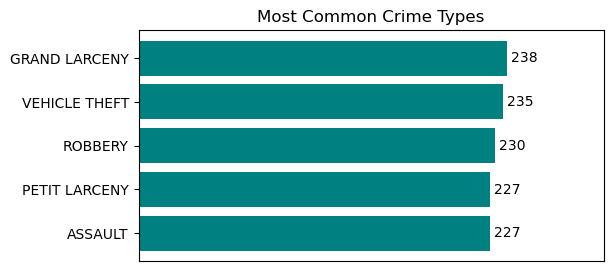

In [39]:
a_df = pd.DataFrame(crime_df['OFNS_DESC_fixed'].value_counts().sort_values(ascending=True).tail(5))
a_df.reset_index(inplace=True)
a_df.columns = ['Crime Type', 'Count']


fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(a_df['Crime Type'],
        a_df['Count'],
        color='teal')

ax.set_title('Most Common Crime Types')
ax.set_xticks([])
ax.set_xlim(0, 300)

for i, v in enumerate(a_df['Count']):
    ax.text(v + 2.5, i, str(v), color='black', va='center')

plt.show()


##### b) Crimes over the years

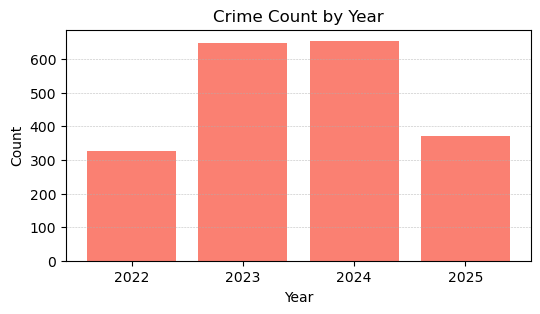

In [40]:
b_df = pd.DataFrame(crime_df['year'].value_counts().sort_index())
b_df.reset_index(inplace=True)
b_df.columns = ['Year', 'Count']

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(b_df['Year'].astype(str),
      b_df['Count'],
      color='salmon')

ax.set_title('Crime Count by Year')
ax.set_ylabel('Count')
ax.set_xlabel('Year')
ax.grid(axis='y', linestyle='--', alpha=0.8, linewidth=0.4)

plt.show()


I included a plot of crime counts by date to show that data is missing from early 2022 and late 2025.

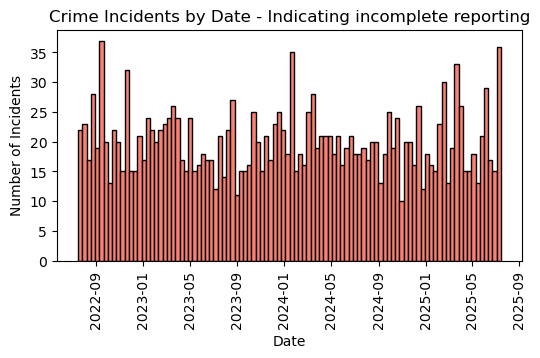

In [41]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(crime_df['CMPLNT_FR_DT'].dropna(),
            bins=100,
            color='salmon',
            edgecolor='black')
ax.tick_params(axis='x', rotation=90)

ax.set_ylabel('Number of Incidents')
ax.set_title('Crime Incidents by Date - Indicating incomplete reporting')
ax.set_xlabel('Date')
plt.show()

##### c) Spotlight on the top 3 boroughs by crime recoreds

I wanted to present the number of crime incidents per borough, using the coordinates to give it a spatial perspective.

I found the raw coordinates a bit messy, so I took a central spot for each borough from Google Maps, to be able to show the boroghs as bubbles over a lat-long plot.

In [42]:
d_df = pd.DataFrame(crime_df['BORO_NM_fixed'].value_counts().sort_values(ascending=False))
d_df.reset_index(inplace=True)
d_df.rename(columns={'BORO_NM_fixed': 'borough'}, inplace=True)

borough_info = {'BRONX': ['BRX',40.8448,-73.8648, 0,'darkgray'],
                'BROOKLYN': ['BKL',40.6782,-73.9442, 1, 'teal'],
                'MANHATTAN': ['MHN',40.7831,-73.9712, 1, 'lightblue'],
                'QUEENS': ['QNS',40.7282,-73.7949, 1, 'salmon'],
                'STATEN ISLAND': ['STI',40.6295,-74.0502, 0, 'darkgray']}

borough_info_df = pd.DataFrame(borough_info).T
borough_info_df.columns = ['ticker', 'latitude', 'longitude','top3','color']
d_df = d_df.merge(borough_info_df, left_on='borough', right_index=True, how='left')

def design_bubble(df,head_size, tail_size):
    '''
    Here I'm adjusting the bubble size
    based on the count of crimes in each borough.
    '''
    for i, row in df.iterrows():
        if row['top3'] == 1:
            df.at[i, 'size'] = np.log(row['count']) * head_size
        else:
            df.at[i, 'size'] = np.log(row['count']) * tail_size
    return df

d_df

,borough,count,ticker,latitude,longitude,top3,color
0,BROOKLYN,417,BKL,40.6782,-73.9442,1,teal
1,QUEENS,404,QNS,40.7282,-73.7949,1,salmon
2,MANHATTAN,400,MHN,40.7831,-73.9712,1,lightblue
3,BRONX,396,BRX,40.8448,-73.8648,0,darkgray
4,STATEN ISLAND,383,STI,40.6295,-74.0502,0,darkgray


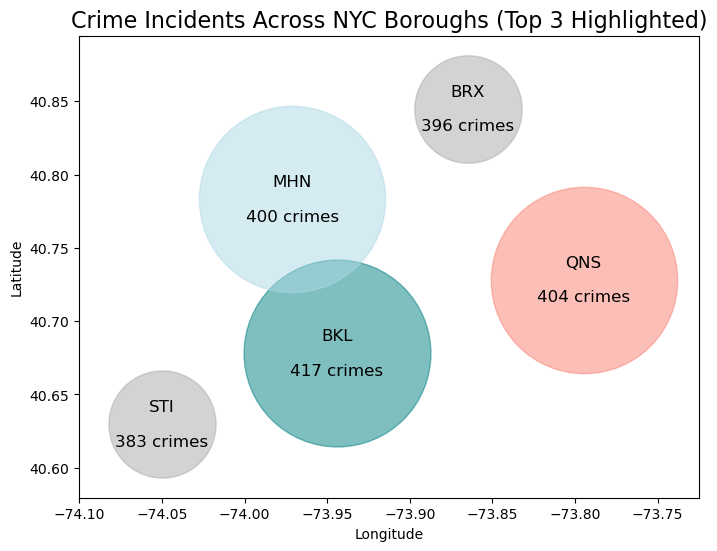

In [45]:
d_df = design_bubble(d_df,3000,1000)

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in d_df.iterrows():
    ax.scatter(row['longitude'],
               row['latitude'],
               s=row['size'],
               alpha=0.5,
               color=row['color'],
               label=row['ticker'])
    ax.text(row['longitude'],
            row['latitude'],
            f"{row['ticker']}\n\n{row['count']} crimes",
            fontsize=12, ha='center', va='center')
    
ax.set_xlim(d_df['longitude'].min() - 0.05,
             d_df['longitude'].max() + 0.07)
ax.set_ylim(d_df['latitude'].min() - 0.05,
             d_df['latitude'].max() + 0.05)

ax.set_title("Crime Incidents Across NYC Boroughs (Top 3 Highlighted)", fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

##### d) Crime severity distribution 

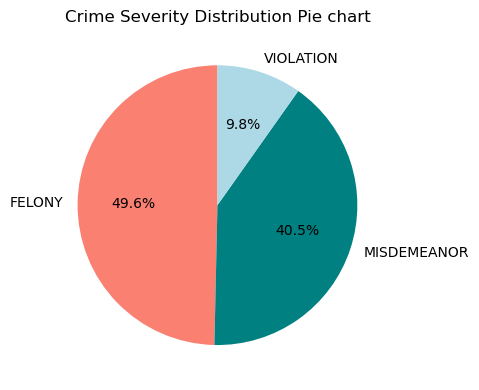

In [22]:
d_df = pd.DataFrame(crime_df['LAW_CAT_CD'].value_counts())
d_df.reset_index(inplace=True)
d_df.columns = ['Severity', 'Count']

fig, ax = plt.subplots(figsize=(8, 4))
ax.pie(d_df['Count'],
        labels=d_df['Severity'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['salmon', 'teal', 'lightblue'],)

ax.set_title('Crime Severity Distribution Pie chart')
plt.tight_layout()
plt.show()